In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.windows import Window

In [2]:
def rgb2hex(r, g, b, a):
    """Converto to hex color rep"""
    return "#{:02x}{:02x}{:02x}{:02x}".format(r, g, b, a)

In [3]:
norm = mpl.colors.Normalize(vmin=-1, vmax=10)
cmap = mpl.colormaps.get("terrain")

In [4]:
for x in range(1, 10):
    print(rgb2hex(*cmap(norm(x), bytes=True)))

#00a8d0ff
#15d06aff
#75e37dff
#d1f58fff
#e8e18cff
#baa673ff
#8a6959ff
#a38983ff
#d1c4c1ff


In [9]:
lognorm = mpl.colors.LogNorm(vmin=0, vmax=17000)
cmap = mpl.colormaps.get("BuPu")

In [112]:
with rio.open("../data/processed/population_cog.tif") as src:
    window = Window(width=src.width / 50, height=src.height / 50, col_off=src.height / 2, row_off=src.width / 2 + 500)
    data = src.read(1, window=window, masked=True)

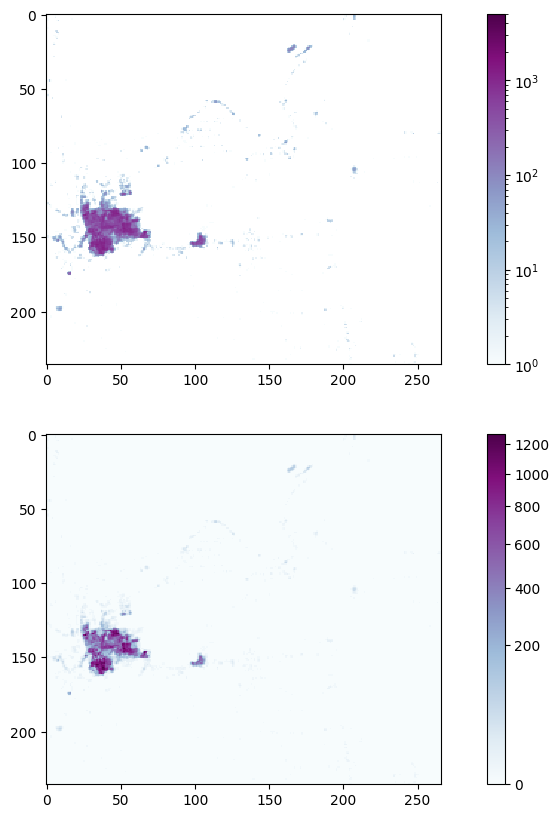

In [129]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
pcm = ax[0].imshow(data, norm=mpl.colors.LogNorm(vmin=1, vmax=5000), cmap=cmap, interpolation="none")
fig.colorbar(pcm, ax=ax[0])

pcm = ax[1].imshow(data, norm=mpl.colors.PowerNorm(gamma=0.5), cmap=cmap, interpolation="none")
fig.colorbar(pcm, ax=ax[1])

In [104]:
mapa = mpl.cm.ScalarMappable(cmap=cmap, norm=lognorm)

In [141]:
import numpy as np

vmin = 1
vmax = 10000
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
cmap = mpl.colormaps.get("BuPu")

for i in np.logspace(10**-vmin, 10**-vmax, 6, base=10):
    color = cmap(norm(i), bytes=True)
    print(f'"{i}": "{rgb2hex(*color)}"')

"1.2589254117941673": "#f2f8fbff"
"1.202264434617413": "#f3f9fbff"
"1.1481536214968828": "#f4fafcff"
"1.096478196143185": "#f5fafcff"
"1.0471285480508996": "#f6fbfcff"
"1.0": "#f7fcfdff"
